In [1]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,12_ema,27_ema,MACD,Signal,MACD_hist,BB_SMA,BB_STD,Upper_Band,Lower_Band,MACD_Strategy,BB_Strategy,Full_Strategy,Strategy,Asset_Returns,Strategy_Returns
7254,442.576294,443.568945,441.952331,443.389318,47858300,440.578243,438.982982,1.595261,1.401874,0.193387,437.133237,5.398244,442.531480,431.734993,NaN,NaN,NaN,0,NaN,NaN
7255,444.079529,444.344238,440.874632,443.616267,50625600,441.133535,439.444329,1.689205,1.459875,0.229330,437.896169,5.237488,443.133656,432.658681,1.0,-1.0,0.0,0,0.003397,0.000000
7256,443.285400,445.223445,442.916683,443.966056,57315600,441.473200,439.785515,1.687685,1.505776,0.181909,438.641612,4.858529,443.500141,433.783083,1.0,-1.0,0.0,0,0.001602,0.000000
7257,442.037476,447.681474,441.829488,445.176188,72762000,441.561914,439.982126,1.579788,1.520666,0.059121,439.209796,4.531120,443.740916,434.678676,1.0,0.0,1.0,0,-0.001217,0.000000
7258,442.623566,443.483877,439.087805,441.706533,73206500,441.728263,440.209137,1.519126,1.520357,-0.001230,439.787901,4.159101,443.947002,435.628800,1.0,0.0,1.0,0,0.000107,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8230,671.159973,673.940002,669.210022,673.530029,66501900,667.501325,660.586778,6.914548,6.938459,-0.023912,664.354843,5.320908,669.675752,659.033935,1.0,-1.0,0.0,0,0.516484,-0.078278
8231,653.020020,673.950012,652.840027,672.130005,159422600,665.273432,660.046295,5.227137,6.596195,-1.369058,664.226224,5.569165,669.795389,658.657059,-1.0,-1.0,-2.0,-1,0.475497,-0.053366
8232,663.039978,665.130005,659.770020,660.650024,79560500,664.929824,660.260129,4.669694,6.210895,-1.541201,664.424088,5.445736,669.869823,658.978352,-1.0,1.0,0.0,0,0.498137,-0.053366
8233,662.229980,665.830017,653.169983,657.169983,88779600,664.514463,660.400833,4.113630,5.791442,-1.677812,664.626825,5.273611,669.900436,659.353213,-1.0,0.0,-1.0,0,0.496307,-0.053366


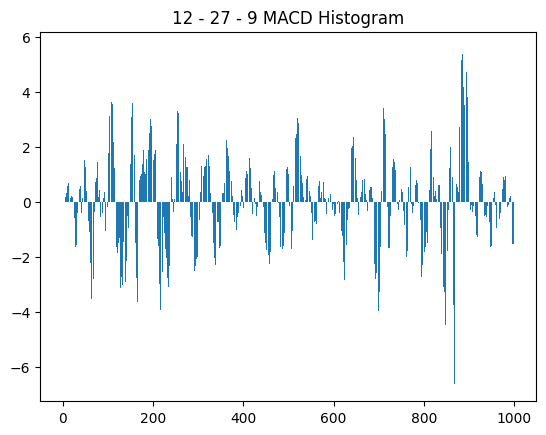

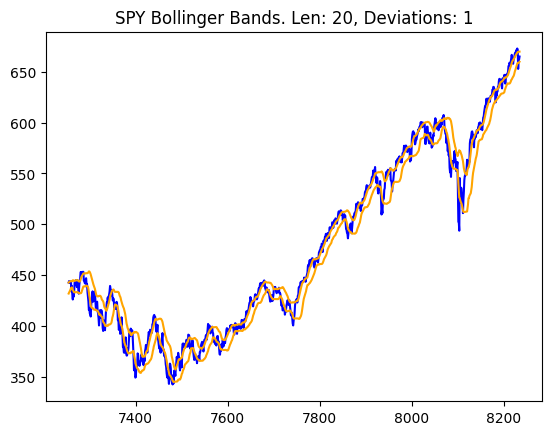

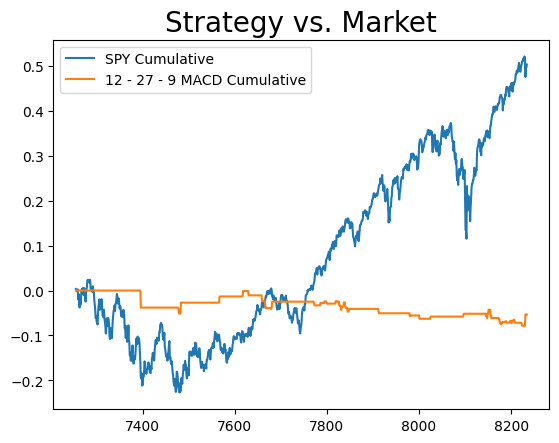

In [2]:
TICKER = 'SPY'
INTERVAL='1d'

# set period based on interval
if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'

MACD_FAST = 12
MACD_SLOW = 27
MACD_SPAN = 9
BB_LEN = 20
DEVS = 1

# what subsetion of that data are you interested in
LOOKBACK = 1000

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):

    # get data at interval you want
    df = yf.download(ticker, interval=interval, period=PERIOD)
    df.columns = df.columns.get_level_values(0)

    # reset the index to make plots prettier
    df = df.reset_index(drop=True)

    # only return the subset of data you are interested in
    return df.iloc[-lookback:, :]

def add_MACD(df, fast=MACD_FAST, slow=MACD_SLOW, span=MACD_SPAN):

    df[f'{fast}_ema'] = df['Close'].ewm(span=fast).mean()
    df[f'{slow}_ema'] = df['Close'].ewm(span=slow).mean()

    # macd line is the difference betweent he fast and slow
    df[f'MACD'] = df[f'{fast}_ema'] - df[f'{slow}_ema']

    # macd signal is a 9-period moving average of this line
    df['Signal'] = df['MACD'].ewm(span=span).mean()

    # MACD histogram is almost always what is used in TA
    df['MACD_hist'] = df['MACD'] - df['Signal']

    # plot the histogram
    plt.bar(x=range(len(df)), height=df['MACD_hist'])
    plt.title(f'{MACD_FAST} - {MACD_SLOW} - {MACD_SPAN} MACD Histogram')

    return df

def add_MACD_strategy(df):

    df['MACD_Strategy'] = 0
    df['MACD_Strategy'] = np.where(df['MACD_hist'] > 0, 1, -1)
    df['MACD_Strategy'] = df['MACD_Strategy'].shift(1)
    
    return df

def add_bollinger_bands(df, devs=DEVS, bb_len=BB_LEN):

    # can change to ema (use MACD video/code for reference)
    df['BB_SMA'] = df['Close'].rolling(bb_len).mean()

    # get the standard deviation of the close prices for the period
    df['BB_STD'] = df['Close'].rolling(bb_len).std()

    df['Upper_Band'] = df['BB_SMA'] + (devs * df['BB_STD'])
    df['Lower_Band'] = df['BB_SMA'] - (devs * df['BB_STD'])

    df = df.dropna()

    plt.figure()
    plt.plot(df['Close'], color='blue')
    plt.plot(df['Upper_Band'], color='orange')
    plt.plot(df['Lower_Band'], color='orange')

    plt.title(f'{TICKER} Bollinger Bands. Len: {BB_LEN}, Deviations: {DEVS}');

    return df

def add_BB_strategy(df):
    df['BB_Strategy'] = 0
    df['BB_Strategy'] = np.where(
        df['Close'] > df['Upper_Band'], -1, 
        np.where(df['Close'] < df['Lower_Band'], 1, 0)
        )
    
    df['BB_Strategy'] = df['BB_Strategy'].shift(1)
    
    return df

def add_full_strategy(df):

    df['Full_Strategy'] = df['MACD_Strategy'] + df['BB_Strategy']

    # adjust values for simplicity
    df['Strategy'] = np.where(df['Full_Strategy'] == 2, 1, 
                     np.where(df['Full_Strategy'] == -2, -1, 0))

    return df

def test_strategy(df):

    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() -1

    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', f'{MACD_FAST} - {MACD_SLOW} - {MACD_SPAN} MACD Cumulative'])
    plt.title('Strategy vs. Market', size='20')

    return df

def main():
    df = get_data()
    df = add_MACD(df)
    df = add_bollinger_bands(df)
    df = add_MACD_strategy(df)
    df = add_BB_strategy(df)
    df = add_full_strategy(df)
    df = test_strategy(df)

    return df

df = main()
df